<a href="https://colab.research.google.com/github/FerasAljayyousi/ML-DL-Projects/blob/main/Iris_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#the goel : Predict the species of a flower based on its petal size

In [ ]:
#import needed laibraris
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
iris = fetch_ucirepo(id=53)

# data (as pandas dataframes)
X = iris.data.features
y = iris.data.targets

# metadata
print(iris.metadata)

# variable information
print(iris.variables)

{'uci_id': 53, 'name': 'Iris', 'repository_url': 'https://archive.ics.uci.edu/dataset/53/iris', 'data_url': 'https://archive.ics.uci.edu/static/public/53/data.csv', 'abstract': 'A small classic dataset from Fisher, 1936. One of the earliest known datasets used for evaluating classification methods.\n', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 150, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1936, 'last_updated': 'Tue Sep 12 2023', 'dataset_doi': '10.24432/C56C76', 'creators': ['R. A. Fisher'], 'intro_paper': {'ID': 191, 'type': 'NATIVE', 'title': 'The Iris data set: In search of the source of virginica', 'authors': 'A. Unwin, K. Kleinman', 'venue': 'Significance, 2021', 'year': 2021, 'journal': 'Significance, 2021', 'DOI': '1740-9713.01589', 'URL': 'https://www.semanticscholar.org

In [ ]:
dataset_path = 'https://archive.ics.uci.edu/static/public/53/'

In [ ]:
os.path.join(dataset_path, 'data.csv')

'https://archive.ics.uci.edu/static/public/53/data.csv'

In [ ]:
df = pd.read_csv(os.path.join(dataset_path, 'data.csv'))

In [ ]:
df

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [ ]:
df.columns

Index(['sepal length', 'sepal width', 'petal length', 'petal width', 'class'], dtype='object')

In [ ]:
df.describe()

,sepal length,sepal width,petal length,petal width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
df.isna().sum()

,0
sepal length,0
sepal width,0
petal length,0
petal width,0
class,0


In [ ]:
df['class'].value_counts()

,count
class,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


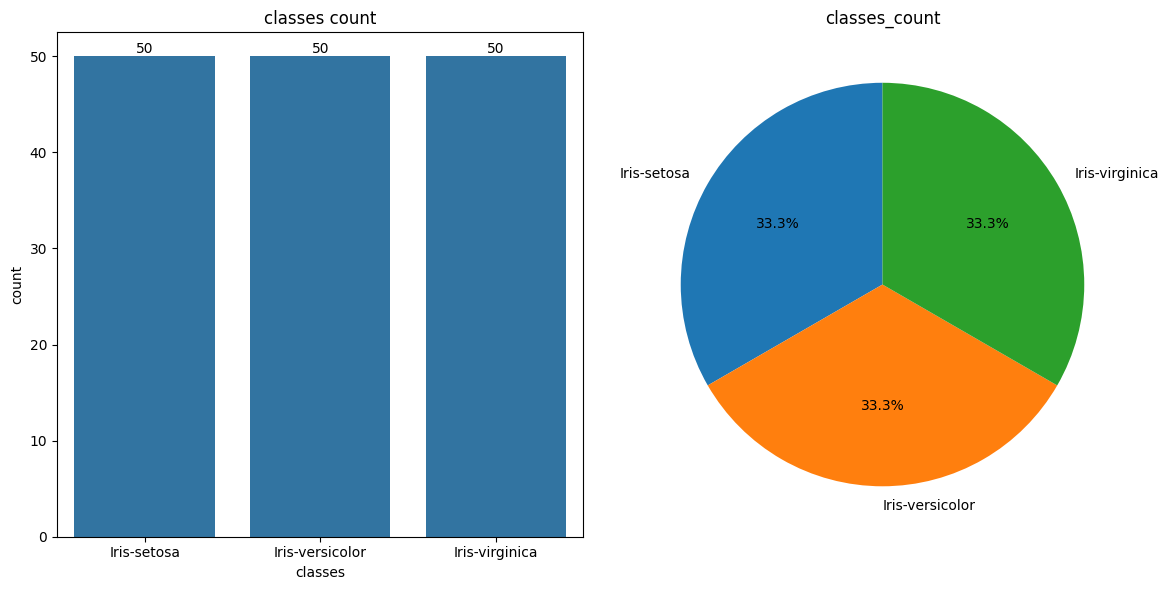

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (12, 6))
# view each class count
class_count = df['class'].value_counts()
#bar plot
sns.barplot(x= class_count.index, y = class_count.values, ax = ax[0])
ax[0].set_title('classes count')
ax[0].set_xlabel('classes')
ax[0].set_ylabel('count')

# Annotate each bar with its count
for i, count in enumerate(class_count):
  ax[0].text(i, count, str(count), ha='center', va='bottom')
#pie chart
ax[1].pie(class_count,  labels= class_count.index,  autopct='%1.1f%%', startangle=90)
ax[1].set_title('classes_count')

plt.tight_layout()
plt.show()

In [ ]:
mean_sepal_length = df.groupby('class')['sepal length'].mean().reset_index()
print(mean_sepal_length)

             class  sepal length
0      Iris-setosa         5.006
1  Iris-versicolor         5.936
2   Iris-virginica         6.588


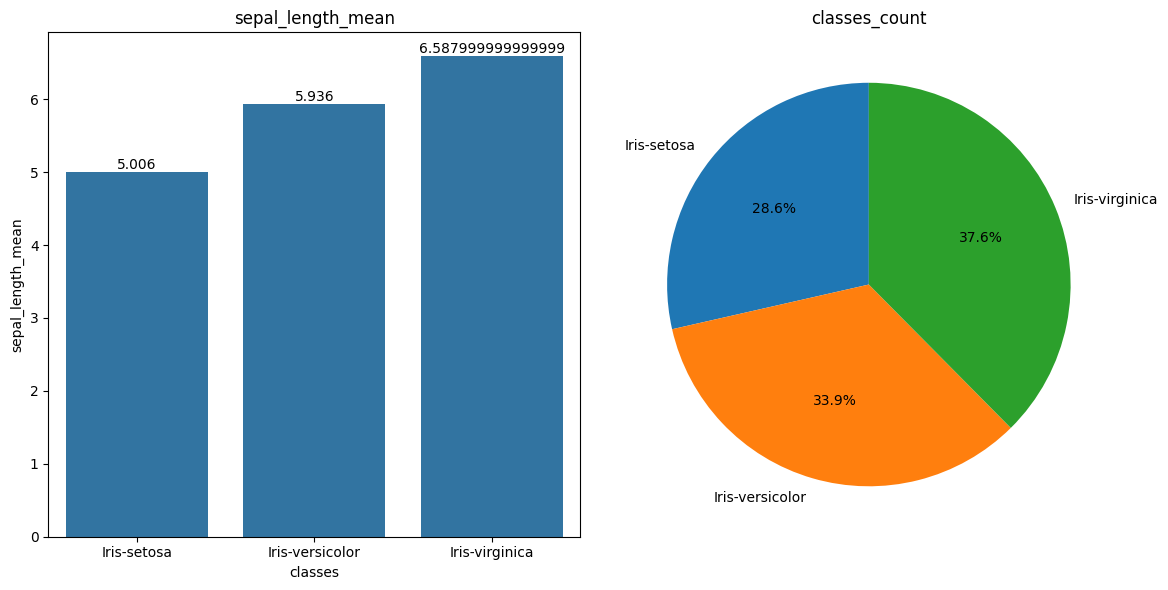

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (12, 6))
# view each class count
mean_sepal_length = df.groupby('class')['sepal length'].mean().reset_index()
#bar plot
sns.barplot(x= mean_sepal_length['class'], y = mean_sepal_length['sepal length'], ax = ax[0])
ax[0].set_title('sepal_length_mean')
ax[0].set_xlabel('classes')
ax[0].set_ylabel('sepal_length_mean')

# Annotate each bar with its count
for i, count in enumerate(mean_sepal_length['sepal length']):
  ax[0].text(i, count, str(count), ha='center', va='bottom')
#pie chart
ax[1].pie(mean_sepal_length['sepal length'],  labels= mean_sepal_length['class'],  autopct='%1.1f%%', startangle=90)
ax[1].set_title('classes_count')

plt.tight_layout()
plt.show()

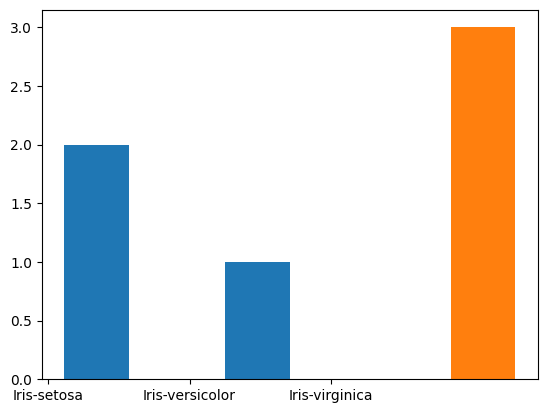

In [ ]:
# fig, ax = plt.subplots(1, 2, figsize = (12, 6))
# # view each class count
mean_sepal_width = df.groupby('class')['sepal width'].mean().reset_index()
# #bar plot
# sns.barplot(x= mean_sepal_width['class'], y = mean_sepal_width['sepal width'], ax = ax[0])
# ax[0].set_title('sepal_width_mean')
# ax[0].set_xlabel('classes')
# ax[0].set_ylabel('mean')

# # Annotate each bar with its count
for i, count in enumerate(mean_sepal_width['sepal width']):
  ax[0].text(i, count, str(count), ha='center', va='bottom')
# #pie chart
# ax[1].pie(mean_sepal_width['sepal width'],  labels= mean_sepal_width['class'],  autopct='%1.1f%%', startangle=90)
# ax[1].set_title('classes_count')

plt.tight_layout()
# plt.show()
bins_num = 3
plt.hist(mean_sepal_width, bins_num)
plt.show()

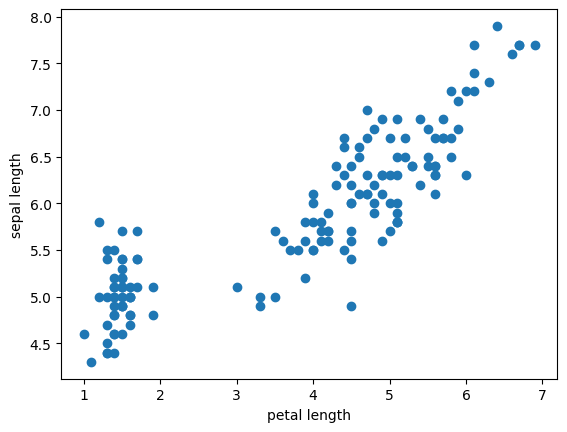

In [ ]:
# mean_petal_length = df.groupby('class')['petal length'].mean().reset_index()
plt.scatter(x=df["petal length"] , y=df['sepal length'])
plt.xlabel('petal length')
plt.ylabel('sepal length')
plt.show()

In [ ]:
# plt.plot(df['petal width'], color='red', label='petal width')
# plt.plot(df['sepal width'], color='blue', label='sepal width')
# plt.legend()
# plt.show()

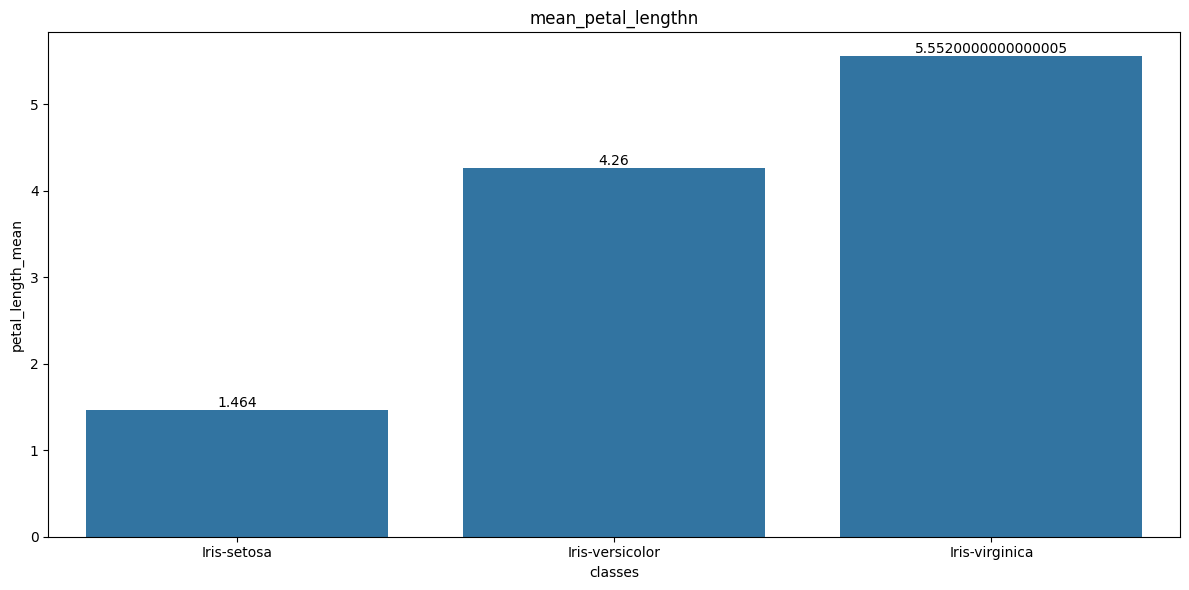

In [ ]:

fig = plt.subplots(1, figsize = (12, 6))
# view each class count
# mean_petal_length = df.groupby('class')['sepal length'].mean().reset_index()
#bar plot
mean_petal_length = df.groupby('class')['petal length'].mean().reset_index()
sns.barplot(x= mean_petal_length['class'], y = mean_petal_length['petal length'])
plt.title('mean_petal_lengthn')
plt.xlabel('classes')
plt.ylabel('petal_length_mean')

# Annotate each bar with its count
for i, count in enumerate(mean_petal_length['petal length']):
  plt.text(i, count, str(count), ha='center', va='bottom')


plt.tight_layout()
plt.show()

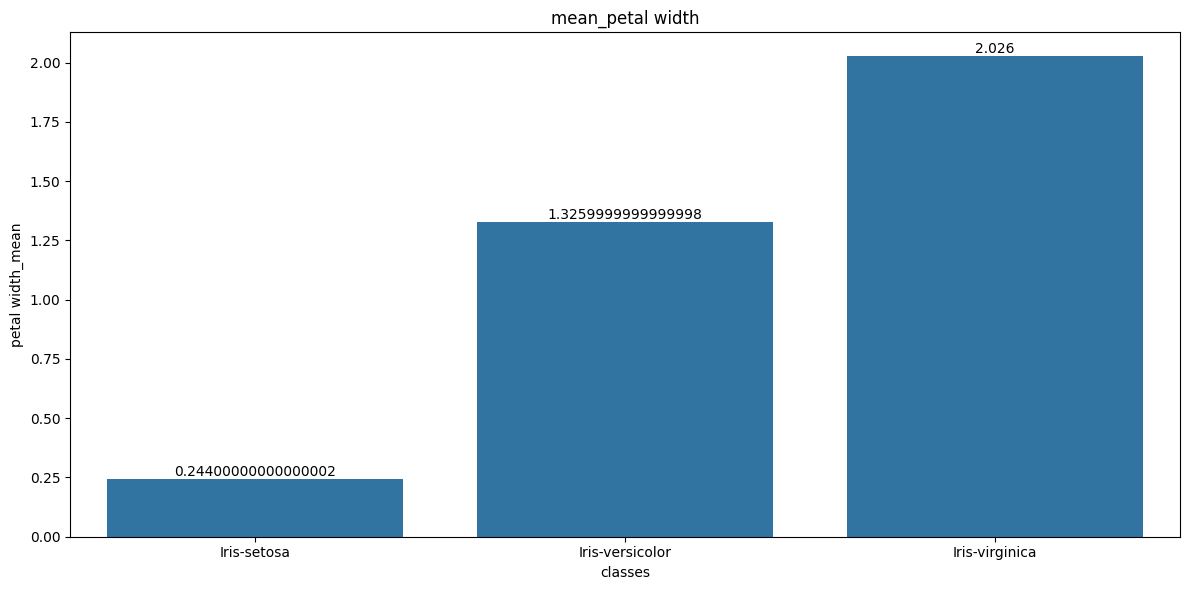

In [ ]:
fig = plt.subplots(1, figsize = (12, 6))
# view each class count
# mean_petal_length = df.groupby('class')['sepal length'].mean().reset_index()
#bar plot
mean_petal_width = df.groupby('class')['petal width'].mean().reset_index()
sns.barplot(x= mean_petal_width['class'], y = mean_petal_width['petal width'])
plt.title('mean_petal width')
plt.xlabel('classes')
plt.ylabel('petal width_mean')

# Annotate each bar with its count
for i, count in enumerate(mean_petal_width['petal width']):
  plt.text(i, count, str(count), ha='center', va='bottom')


plt.tight_layout()
plt.show()

In [ ]:
df

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df[['sepal length', 'sepal width', 'petal length','petal width']], df['class'], test_size=0.2, random_state=42)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (120, 4)
Shape of X_test: (30, 4)
Shape of y_train: (120,)
Shape of y_test: (30,)


In [ ]:
# This ensures scaling only happens on the folds/data provided during 'fit'
pipeline = Pipeline([('scaler', StandardScaler()),('classifier', LogisticRegression())])
pipeline.fit(X_train, y_train)
accuracy = pipeline.score(X_test, y_test)

In [ ]:
print(X_test.head())

     sepal length  sepal width  petal length  petal width
73            6.1          2.8           4.7          1.2
18            5.7          3.8           1.7          0.3
118           7.7          2.6           6.9          2.3
78            6.0          2.9           4.5          1.5
76            6.8          2.8           4.8          1.4


In [ ]:
# Building models using Pipelines to ensure proper scaling
knn_pipeline = Pipeline([('scaler', StandardScaler()), ('classifier', KNeighborsClassifier(n_neighbors=7))])
log_pipeline = Pipeline([('scaler', StandardScaler()), ('classifier', LogisticRegression())])
svm_pipeline = Pipeline([('scaler', StandardScaler()), ('classifier', SVC(kernel='linear'))])
lda_pipeline = Pipeline([('scaler', StandardScaler()), ('classifier', LinearDiscriminantAnalysis())])

In [ ]:
knn_pipeline.fit(X_train, y_train)
log_pipeline.fit(X_train, y_train)
svm_pipeline.fit(X_train, y_train)
lda_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', LinearDiscriminantAnalysis())])

In [ ]:
# prediction using pipelines (automatically scales X_test)
knn_pred = knn_pipeline.predict(X_test)
log_pred = log_pipeline.predict(X_test)
svm_pred = svm_pipeline.predict(X_test)
lda_pred = lda_pipeline.predict(X_test)


--- KNN Evaluation ---
Test Accuracy: 100.00%
Train Accuracy: 95.83%
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



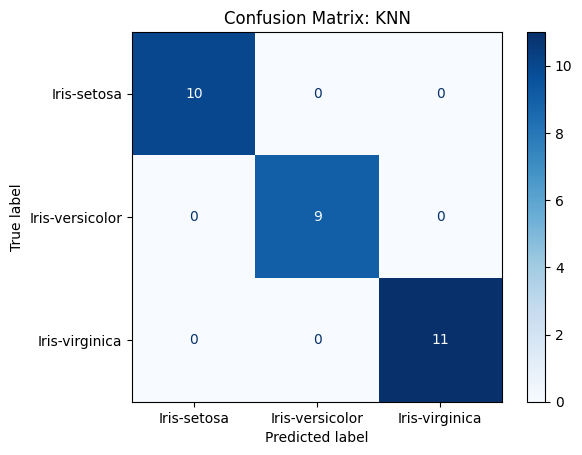


--- Logistic Regression Evaluation ---
Test Accuracy: 100.00%
Train Accuracy: 96.67%
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



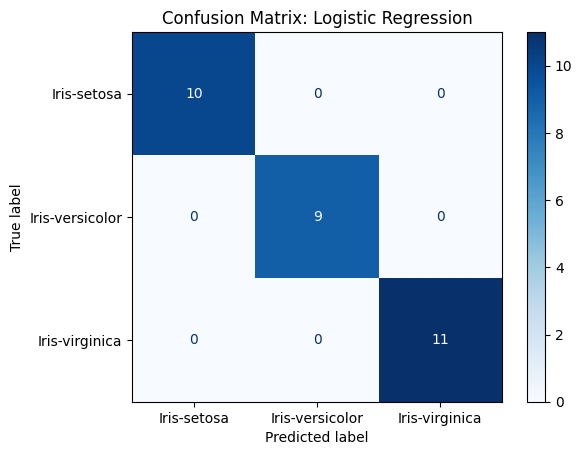


--- SVM Evaluation ---
Test Accuracy: 96.67%
Train Accuracy: 98.33%
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.89      0.94         9
 Iris-virginica       0.92      1.00      0.96        11

       accuracy                           0.97        30
      macro avg       0.97      0.96      0.97        30
   weighted avg       0.97      0.97      0.97        30



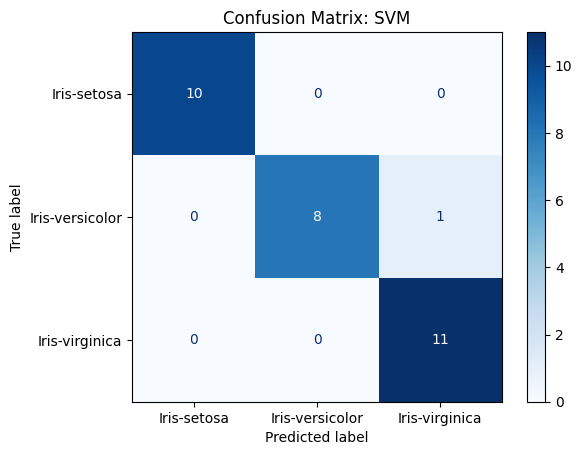


--- LDA Evaluation ---
Test Accuracy: 100.00%
Train Accuracy: 97.50%
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



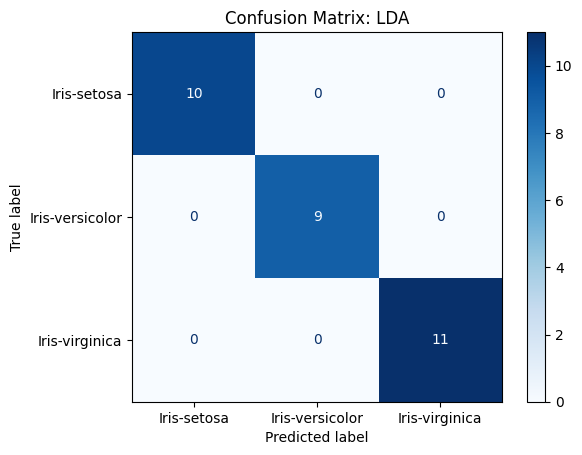

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    "KNN": knn_pipeline,
    "Logistic Regression": log_pipeline,
    "SVM": svm_pipeline,
    "LDA": lda_pipeline
}

for name, model in models.items():
    print(f"\n--- {name} Evaluation ---")
    y_pred = model.predict(X_test)
    print(f"Test Accuracy: {model.score(X_test, y_test):.2%}")
    print(f"Train Accuracy: {model.score(X_train, y_train):.2%}")
    print(classification_report(y_test, y_pred))

    # Plotting Confusion Matrix
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
    plt.title(f"Confusion Matrix: {name}")
    plt.show()